# Retrain Sign-O-Text: 7 WLASL Classes

Retrains the LSTM model on 7 sign classes:
**hello, thanks, Father, Mother, Yes, No, Help**

## Setup
1. Run in **Google Colab with T4 GPU** (Runtime > Change runtime type > T4 GPU)
2. Upload your .npy data files to Google Drive
3. Mount Drive below.


In [1]:
pip install --upgrade "numpy>=2.0.0" "protobuf>=5.29.1" "tensorflow==2.20.0" "ml-dtypes>=0.5.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 21.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-aiplatform 1.148.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.
google-cloud-bigtable 2.36.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.
google-ai-gen

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
print('TensorFlow version:', tf.__version__)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0


In [2]:
DATA_DIR = Path('/content/drive/MyDrive/landmarks.zip')

In [3]:
import zipfile
from pathlib import Path

ZIP_PATH = Path('/content/drive/MyDrive/landmarks.zip')
DATA_DIR = Path('/content/landmarks')

# Extract only if not already done
if not DATA_DIR.exists():
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print('Done!')

print('Data directory:', DATA_DIR)
dirs = [d.name for d in DATA_DIR.iterdir() if d.is_dir()]
print('Found class directories:', dirs)

Extracting...
Done!
Data directory: /content/landmarks
Found class directories: ['landmarks']


In [4]:
# Check what's actually inside DATA_DIR
import os

for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(str(DATA_DIR), '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  # only show files up to 3 levels deep
        for f in files[:3]:
            print(f'{indent}  {f}')

landmarks/
  landmarks/
    thanks/
      57611_seq136.npz
      57611_seq084.npz
      57611_seq026.npz
    Yes/
      64275_seq004.npz
      64275_seq008.npz
      64275_seq007.npz
    No/
      38538_seq000.npz
      38482_seq023.npz
      38482_seq040.npz
    Father/
      21202_seq112.npz
      21202_seq107.npz
      21202_seq053.npz
    hello/
      27171_seq042.npz
      27171_seq007.npz
      27171_seq027.npz
    Mother/
      36927_seq067.npz
      36927_seq060.npz
      36927_seq025.npz
    Help/
      27194_seq091.npz
      27194_seq062.npz
      27194_seq067.npz


In [5]:
from pathlib import Path
import numpy as np

DATA_DIR = Path('/content/landmarks/landmarks')

SEQUENCE_LENGTH = 30
FEATURE_LENGTH = 126
CLASSES = ['hello', 'thanks', 'Father', 'Mother', 'Yes', 'No', 'Help']

def load_data(data_dir):
    X, y = [], []
    for idx, class_name in enumerate(CLASSES):
        class_dir = data_dir / class_name
        if not class_dir.exists():
            print(f'MISSING: {class_name}')
            continue
        npy_files = list(class_dir.glob('*.npy')) + list(class_dir.glob('*.npz'))
        valid = 0
        for f in npy_files:
            data = np.load(f)
            if f.suffix == '.npz':
                data = data[list(data.keys())[0]]
            if data.shape == (SEQUENCE_LENGTH, FEATURE_LENGTH):
                X.append(data)
                y.append(idx)
                valid += 1
        print(f'{class_name}: {len(npy_files)} files, {valid} valid')
    X = np.array(X)
    y = np.array(y)
    print(f'Total: {len(X)} sequences, {len(np.unique(y))}/{len(CLASSES)} classes')
    return X, y

# ✅ Call AFTER the function is defined
X, y = load_data(DATA_DIR)
print('Input shape:', X.shape)
print(f'Memory: {X.nbytes / 1024 / 1024:.1f} MB (float16 saves 2x vs float32)')

hello: 150 files, 150 valid
thanks: 150 files, 150 valid
Father: 120 files, 120 valid
Mother: 101 files, 101 valid
Yes: 19 files, 19 valid
No: 77 files, 77 valid
Help: 92 files, 92 valid
Total: 709 sequences, 7/7 classes
Input shape: (709, 30, 126)
Memory: 5.1 MB (float16 saves 2x vs float32)


In [6]:
def augment_sequence(seq, num_augments=50):
    # Vectorized: generate all augments at once
    noise = np.random.normal(0, 0.02, (num_augments, *seq.shape))
    scales = 1.0 + np.random.uniform(-0.05, 0.05, (num_augments, 1, 1))
    shifts = np.random.uniform(-0.03, 0.03, (num_augments, 1, seq.shape[1]))

    augs = seq[np.newaxis] + noise  # broadcast over num_augments
    augs *= scales
    augs += shifts
    return augs  # shape: (num_augments, 30, 126)

def augment_dataset(X, y, n=50):
    X_aug = np.concatenate([augment_sequence(X[i], n) for i in range(len(X))])
    y_aug = np.repeat(y, n)
    return X_aug, y_aug

print(f'Augmenting 50x (from {len(X)} to {len(X)*50} sequences)...')
X_aug, y_aug = augment_dataset(X, y, n=50)
print(f'After augmentation: {X_aug.shape}')

Augmenting 50x (from 709 to 35450 sequences)...
After augmentation: (35450, 30, 126)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_aug, y_aug, test_size=0.15, random_state=42, stratify=y_aug
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (30132, 30, 126), Test: (5318, 30, 126)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

NUM_CLASSES = len(CLASSES)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQUENCE_LENGTH, FEATURE_LENGTH)),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(128, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(64),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        48,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,615 (799.28 KB)

 Trainable params: 204,103 (797.28 KB)

 Non-trainable params: 512 (2.00 KB)

In [9]:
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_action_7.keras',
    monitor='val_accuracy', save_best_only=True, mode='max'
)
early_stop = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150, batch_size=32,
    callbacks=[checkpoint, early_stop, lr_scheduler],
    verbose=1
)


Epoch 1/150
942/942 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.3062 - loss: 1.6935 - val_accuracy: 0.3921 - val_loss: 1.4939 - learning_rate: 0.0010
Epoch 2/150
942/942 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.4510 - loss: 1.3477 - val_accuracy: 0.5613 - val_loss: 1.0541 - learning_rate: 0.0010
Epoch 3/150
942/942 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.6463 - loss: 0.8424 - val_accuracy: 0.7964 - val_loss: 0.4256 - learning_rate: 0.0010
Epoch 4/150
942/942 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.7655 - loss: 0.5160 - val_accuracy: 0.7292 - val_loss: 0.7423 - learning_rate: 0.0010
Epoch 5/150
942/942 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.8107 - loss: 0.3743 - val_accuracy: 0.8298 - val_loss: 0.3544 - learning_rate: 0.0010
Epoch 6/150
942/942 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.8339 - loss: 0.3201 - val_accuracy: 0.7619 - val_loss: 0.6833 - learning_rate: 0.0010
Epoch 7/150
942/942 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.8

In [10]:
y_pred = np.argmax(model.predict(X_test), axis=1)
acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.3f} ({acc*100:.1f}%)')
print('Per-class accuracy:')
cm = confusion_matrix(y_test, y_pred)
for i, name in enumerate(CLASSES):
    if i < cm.shape[0] and cm[i].sum() > 0:
        ca = cm[i,i] / cm[i].sum()
        print(f'{name:8s}: {ca:.2f} ({cm[i,i]}/{cm[i].sum()})')


167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Test accuracy: 0.876 (87.6%)
Per-class accuracy:
hello   : 0.56 (630/1125)
thanks  : 1.00 (1125/1125)
Father  : 1.00 (900/900)
Mother  : 1.00 (758/758)
Yes     : 1.00 (142/142)
No      : 1.00 (578/578)
Help    : 0.76 (527/690)


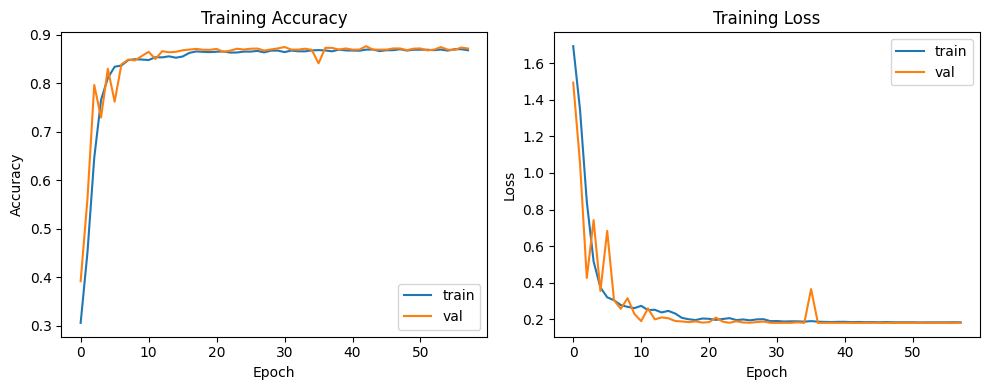

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss')
plt.tight_layout()
plt.show()


In [12]:
final_path = '/content/drive/MyDrive/action_wlasl_7.keras'
model.save(final_path)
print(f'Model saved to: {final_path}')
import json
with open('/content/drive/MyDrive/classes_7.json', 'w') as f:
    json.dump(CLASSES, f, indent=2)
print('Class order saved.')


Model saved to: /content/drive/MyDrive/action_wlasl_7.keras
Class order saved.


In [13]:
from google.colab import files
files.download(final_path)
print('Done! Copy action_wlasl_7.keras to your project model/ folder')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Copy action_wlasl_7.keras to your project model/ folder


## Summary
Data: WLASL (hello, thanks, Father, Mother, Yes, No, Help)
Augmentation: 50x expansion via noise, scaling, shift
Output: Download action_wlasl_7.keras to your project
